**Training of Computer Vision Model**

In [1]:
!pip install ultralytics

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from pathlib import Path

root = Path("../../data/raw_data/final_unified_dataset")
print("Dataset exists:", root.exists())
print("Train images:", (root / "images/train").exists())
print("Val images:", (root / "images/val").exists())
print("Test images:", (root / "images/test").exists())
print("Train labels:", (root / "labels/train").exists())
print("Val labels:", (root / "labels/val").exists())
print("Test labels:", (root / "labels/test").exists())
print("YAML exists:", (root / "dataset.yaml").exists())
print(Path("../../data/raw_data/final_unified_dataset/dataset.yaml").read_text())

Dataset exists: True
Train images: True
Val images: True
Test images: True
Train labels: True
Val labels: True
Test labels: True
YAML exists: True
path: /Users/anbu/Sri/CDS_2026Spring_project/data/raw_data/final_unified_dataset
train: images/train
val: images/val
test: images/test

names:
  0: person
  1: bag


**Experimental Models**

In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
results = model.train(
    data="../../data/raw_data/final_unified_dataset/dataset.yaml",
    epochs=20,
    imgsz=640,
    batch=8,
    device = "mps"
)
metrics = model.val()
print(metrics)

In [ ]:
model = YOLO("yolov8s.pt") 

results = model.train(
    data="../../data/raw_data/final_unified_dataset/dataset.yaml",
    epochs=20,
    imgsz=640,
    batch=8,
    device="mps",
    workers=4,
    patience=20,
    project="yolov8s"
)

In [ ]:
model = YOLO("yolov8n.pt") 

results = model.train(
    data="../../data/raw_data/final_unified_dataset/dataset.yaml",
    epochs=20,
    imgsz=640,
    batch=10,
    device="mps",
    workers=2,
    patience=20,
    project="yolov8n"
)


In [ ]:
#Checking for class distribution
import os
from collections import Counter

label_dir = "../../data/raw_data/final_unified_dataset/labels/train"
class_counts = Counter()

for fname in os.listdir(label_dir):
    if not fname.endswith(".txt"):
        continue
    with open(os.path.join(label_dir, fname)) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                class_counts[int(parts[0])] += 1

print("Class distribution in val labels:")
for cls_id, count in sorted(class_counts.items()):
    print(f"  Class {cls_id}: {count} instances")

In [ ]:
#Trying out a newer model

from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data="../../data/raw_data/final_unified_dataset/dataset.yaml",
    epochs=20,              
    imgsz=640,
    batch=10,
    device="mps",
    workers=0,
    patience=20,
    project="yolo11n",
)

*Re-running YOLOv11 on the updated dataset with more people*

In [9]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data="../../data/raw_data/final_unified_dataset/dataset.yaml",
    epochs=20,              
    imgsz=640,
    batch=10,
    device="mps",
    workers=0,
    patience=20,
    project="yolo11n_Updated_Dataset",
    cache =True
)

Ultralytics 8.4.21 🚀 Python-3.13.7 torch-2.10.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=10, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../data/raw_data/final_unified_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspecti

In [23]:
import os
from collections import Counter

base = "../../data/raw_data/final_unified_dataset"

for split in ["train", "val", "test"]:
    label_dir = os.path.join(base, "labels", split)
    counter = Counter()
    for file in os.listdir(label_dir):
        if file.endswith(".txt"):
            with open(os.path.join(label_dir, file)) as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        counter[int(parts[0])] += 1
    print(f"{split}: person={counter[0]}, bag={counter[1]}, ratio={counter[1]/counter[0]:.1f}x")

train: person=10761, bag=3078, ratio=0.3x
val: person=789, bag=651, ratio=0.8x
test: person=830, bag=393, ratio=0.5x


In [17]:
import os

base = "../../data/raw_data/final_unified_datasetv1"

for split in ["train", "val", "test"]:
    label_dir = os.path.join(base, "labels", split)
    
    person_only = bag_only = both = empty = 0
    
    for fname in os.listdir(label_dir):
        if not fname.endswith(".txt"):
            continue
        classes = set()
        with open(os.path.join(label_dir, fname)) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    classes.add(int(parts[0]))
        
        if not classes:
            empty += 1
        elif classes == {0}:
            person_only += 1
        elif classes == {1}:
            bag_only += 1
        elif 0 in classes and 1 in classes:
            both += 1
    
    print(f"\n{split}:")
    print(f"  Person only: {person_only}")
    print(f"  Bag only:    {bag_only}")
    print(f"  Both:        {both}")
    print(f"  Empty:       {empty}")


train:
  Person only: 140
  Bag only:    2498
  Both:        0
  Empty:       1

val:
  Person only: 31
  Bag only:    597
  Both:        0
  Empty:       0

test:
  Person only: 21
  Bag only:    354
  Both:        0
  Empty:       0


Your model   — people found: 0
COCO model   — people found: 1


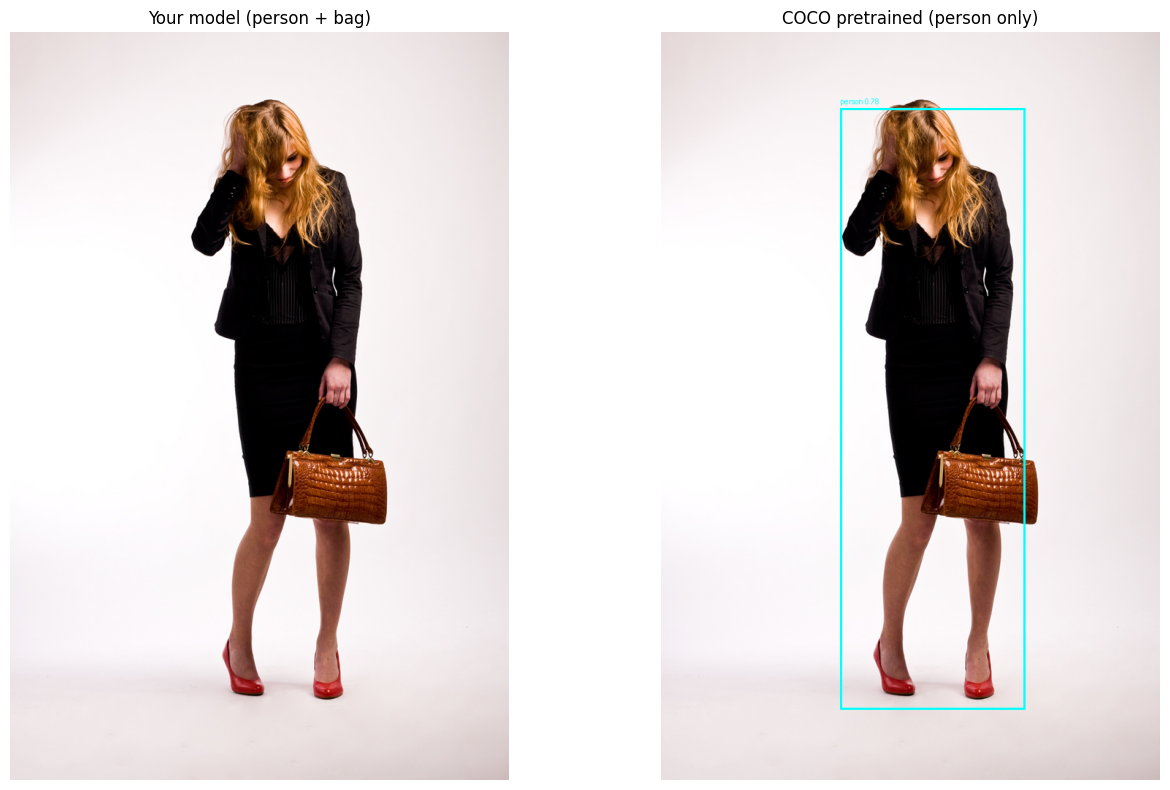

In [1]:
from ultralytics import YOLO

test_image = "../../data/raw_data/final_unified_datasetv1/images/train/0d574e297bf42ad9.jpg"

# Your trained model
your_model = YOLO("../../runs/detect/yolo11n/train/weights/best.pt")

# Pretrained COCO
coco_model = YOLO("yolov8n.pt")

# Your model — person detections only
your_results = your_model.predict(test_image, classes=[0], conf=0.25, verbose=False)

# COCO model — person detections only  
coco_results = coco_model.predict(test_image, classes=[0], conf=0.25, verbose=False)

print(f"Your model   — people found: {len(your_results[0].boxes)}")
print(f"COCO model   — people found: {len(coco_results[0].boxes)}")

from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

def draw_boxes(image_path, results, title):
    img = Image.open(image_path).copy()
    draw = ImageDraw.Draw(img)
    w, h = img.size
    
    for box in results[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])
        cls  = int(box.cls[0])
        color = "cyan" if cls == 0 else "orange"
        label = f"{'person' if cls==0 else 'bag'} {conf:.2f}"
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
        draw.text((x1, y1-15), label, fill=color)
    
    return img

# Run both models showing ALL detections
your_all  = your_model.predict(test_image, conf=0.25, verbose=False)
coco_all  = coco_model.predict(test_image, conf=0.25, verbose=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
axes[0].imshow(draw_boxes(test_image, your_all,  "Your model"))
axes[0].set_title("Your model (person + bag)")
axes[0].axis("off")
axes[1].imshow(draw_boxes(test_image, coco_all,  "COCO pretrained"))
axes[1].set_title("COCO pretrained (person only)")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("model_comparison_visual.png", dpi=100)
plt.show()

In [14]:
import os

label_dir = "../../data/raw_data/final_unified_dataset/labels/train"
label_path = os.path.join(label_dir, "0d574e297bf42ad9.txt")

if os.path.exists(label_path):
    with open(label_path) as f:
        lines = f.readlines()
    
    print(f"Found: {label_path}")
    print(f"Number of annotations: {len(lines)}")
    print()
    
    class_names = {0: "person", 1: "bag"}
    for i, line in enumerate(lines):
        parts = line.strip().split()
        if parts:
            cls = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:])
            print(f"Annotation {i+1}:")
            print(f"  Class:  {cls} ({class_names.get(cls, 'unknown')})")
            print(f"  Center: ({cx:.4f}, {cy:.4f})")
            print(f"  Size:   {bw:.4f} x {bh:.4f}")
else:
    print(f"Not found in train labels: {label_path}")
    
    # Search all splits
    base = "../../data/raw_data/final_unified_dataset/labels"
    for split in ["train", "val", "test"]:
        path = os.path.join(base, split, "0d574e297bf42ad9.txt")
        if os.path.exists(path):
            print(f"Found in {split}: {path}")

Found: ../../data/raw_data/final_unified_dataset/labels/train/0d574e297bf42ad9.txt
Number of annotations: 1

Annotation 1:
  Class:  1 (bag)
  Center: (0.6356, 0.5713)
  Size:   0.2462 x 0.1742


In [13]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Randomly sample and visualise person-labelled images
img_dir   = "../../data/raw_data/final_unified_dataset/images/train"
label_dir = "../../data/raw_data/final_unified_dataset/labels/train"

# Find images that have person labels (class 0)
person_images = []
for fname in os.listdir(label_dir):
    if not fname.endswith(".txt"):
        continue
    with open(os.path.join(label_dir, fname)) as f:
        for line in f:
            if line.startswith("0 "):
                person_images.append(fname.replace(".txt", ".jpg"))
                break

print(f"Found {len(person_images)} images with person labels")

# Plot 9 random samples
sample = random.sample(person_images, min(9, len(person_images)))
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for ax, fname in zip(axes.flat, sample):
    img_path = os.path.join(img_dir, fname)
    lbl_path = os.path.join(label_dir, fname.replace(".jpg", ".txt"))

    if not os.path.exists(img_path):
        continue

    img = Image.open(img_path)
    w, h = img.size
    ax.imshow(img)

    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            cls = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:])

            x1 = (cx - bw/2) * w
            y1 = (cy - bh/2) * h
            bw_px = bw * w
            bh_px = bh * h

            color = "cyan" if cls == 0 else "orange"
            label = "person" if cls == 0 else "bag"

            rect = patches.Rectangle(
                (x1, y1), bw_px, bh_px,
                linewidth=2, edgecolor=color, facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(x1, y1-5, label, color=color, fontsize=8)

    ax.set_title(fname[:30])
    ax.axis("off")

plt.tight_layout()
plt.savefig("label_verification.png", dpi=100)
plt.show()

Found 2753 images with person labels


<Figure size 1500x1500 with 9 Axes>

Trying the combination of pe-built person detection and the old dataset's bag detection

In [4]:
from ultralytics import YOLO

yolo_model = YOLO("../../runs/detect/yolo11n_Updated_Dataset/train/weights/best.pt")

yolo_metrics = yolo_model.val(
    data="../../data/raw_data/final_unified_dataset/dataset.yaml",
    split="val",
    verbose=False,
)

yolo_results = {
    "mAP50":        yolo_metrics.box.map50,
    "mAP50-95":     yolo_metrics.box.map,
    "precision":    yolo_metrics.box.mp,
    "recall":       yolo_metrics.box.mr,
    "person_mAP50": yolo_metrics.box.ap50[0],
    "bag_mAP50":    yolo_metrics.box.ap50[1],
    "inference_ms": yolo_metrics.speed["inference"],
}

print("YOLO11n results:")
for k, v in yolo_results.items():
    print(f"  {k}: {v:.4f}")

Ultralytics 8.4.21 🚀 Python-3.13.7 torch-2.10.0 CPU (Apple M4)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.1 ms, read: 613.0±399.0 MB/s, size: 247.2 KB)
val: Scanning /Users/anbu/Sri/CDS_2026Spring_project/data/raw_data/final_unified_dataset/labels/val.cache... 925 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 925/925 184.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 58/58 1.7s/it 1:401.5sss
                   all        925       1440      0.661      0.588      0.585      0.371
Speed: 0.2ms preprocess, 104.7ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /Users/anbu/Sri/CDS_2026Spring_project/runs/detect/val2
YOLO11n results:
  mAP50: 0.5846
  mAP50-95: 0.3713
  precision: 0.6606
  recall: 0.5877
  person_mAP50: 0.2703
  bag_mAP50: 0.8988
  inference_ms: 104.6627


In [ ]:
import os
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict
import time

# ── Dataset ──────────────────────────────────────────────────────────────────

class YOLOFormatDataset(Dataset):
    """Loads YOLO format labels and converts to Faster R-CNN format"""

    def __init__(self, img_dir, label_dir):
        self.img_dir   = img_dir
        self.label_dir = label_dir
        self.imgs = [
            f for f in os.listdir(img_dir)
            if f.endswith((".jpg", ".png"))
        ]

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        fname    = self.imgs[idx]
        img_path = os.path.join(self.img_dir, fname)
        lbl_path = os.path.join(
            self.label_dir,
            fname.replace(".jpg", ".txt").replace(".png", ".txt")
        )

        img = Image.open(img_path).convert("RGB")
        w, h = img.size

        # Convert to tensor
        img_tensor = torchvision.transforms.functional.to_tensor(img)

        boxes  = []
        labels = []

        if os.path.exists(lbl_path):
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if not parts:
                        continue
                    cls, cx, cy, bw, bh = map(float, parts)

                    # YOLO normalised → absolute pixel coordinates
                    x1 = (cx - bw/2) * w
                    y1 = (cy - bh/2) * h
                    x2 = (cx + bw/2) * w
                    y2 = (cy + bh/2) * h

                    # Clamp to image boundaries
                    x1, y1 = max(0, x1), max(0, y1)
                    x2, y2 = min(w, x2), min(h, y2)

                    if x2 > x1 and y2 > y1:
                        boxes.append([x1, y1, x2, y2])
                        labels.append(int(cls) + 1)  # R-CNN uses 1-indexed, 0=background

        if boxes:
            boxes_tensor  = torch.tensor(boxes,  dtype=torch.float32)
            labels_tensor = torch.tensor(labels, dtype=torch.int64)
        else:
            boxes_tensor  = torch.zeros((0, 4), dtype=torch.float32)
            labels_tensor = torch.zeros((0,),   dtype=torch.int64)

        target = {
            "boxes":    boxes_tensor,
            "labels":   labels_tensor,
            "image_id": torch.tensor([idx]),
        }

        return img_tensor, target


def collate_fn(batch):
    return tuple(zip(*batch))


# ── Model ─────────────────────────────────────────────────────────────────────

def build_model(num_classes):
    """
    num_classes = your classes + 1 background
    So for person + bag: num_classes = 3
    """
    model = fasterrcnn_resnet50_fpn(pretrained=True)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


# ── Evaluation ────────────────────────────────────────────────────────────────

def compute_iou(box1, box2):
    """Compute IoU between two boxes [x1,y1,x2,y2]"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2-x1) * max(0, y2-y1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0


def compute_ap(precisions, recalls):
    """Compute Average Precision using 11-point interpolation"""
    ap = 0
    for t in np.arange(0, 1.1, 0.1):
        prec = [p for p, r in zip(precisions, recalls) if r >= t]
        ap += max(prec) if prec else 0
    return ap / 11


def evaluate(model, dataloader, device, iou_threshold=0.5):
    model.eval()

    # class_id → list of (confidence, is_tp)
    all_detections = defaultdict(list)
    all_gt_counts  = defaultdict(int)

    with torch.no_grad():
        for images, targets in dataloader:
            images = [img.to(device) for img in images]
            preds  = model(images)

            for pred, target in zip(preds, targets):
                gt_boxes  = target["boxes"].cpu().numpy()
                gt_labels = target["labels"].cpu().numpy()

                pred_boxes  = pred["boxes"].cpu().numpy()
                pred_labels = pred["labels"].cpu().numpy()
                pred_scores = pred["scores"].cpu().numpy()

                # Count ground truth per class
                for lbl in gt_labels:
                    all_gt_counts[lbl] += 1

                # Match predictions to ground truth
                matched_gt = set()
                for box, lbl, score in sorted(
                    zip(pred_boxes, pred_labels, pred_scores),
                    key=lambda x: -x[2]
                ):
                    gt_indices = np.where(gt_labels == lbl)[0]
                    best_iou, best_idx = 0, -1

                    for gi in gt_indices:
                        iou = compute_iou(box, gt_boxes[gi])
                        if iou > best_iou:
                            best_iou = iou
                            best_idx = gi

                    is_tp = (
                        best_iou >= iou_threshold and
                        best_idx not in matched_gt
                    )

                    if is_tp:
                        matched_gt.add(best_idx)

                    all_detections[lbl].append((score, is_tp))

    # Compute AP per class
    class_names = {1: "person", 2: "bag"}
    aps = {}

    for cls_id, dets in all_detections.items():
        dets.sort(key=lambda x: -x[0])
        tp_cumsum = np.cumsum([d[1] for d in dets])
        total     = len(dets)
        gt_count  = all_gt_counts[cls_id]

        precisions = tp_cumsum / (np.arange(total) + 1)
        recalls    = tp_cumsum / gt_count if gt_count > 0 else np.zeros(total)

        ap = compute_ap(precisions.tolist(), recalls.tolist())
        aps[cls_id] = ap
        name = class_names.get(cls_id, f"class_{cls_id}")
        print(f"  {name}: AP50={ap:.4f}")

    map50 = np.mean(list(aps.values())) if aps else 0
    print(f"  mAP50: {map50:.4f}")
    return map50, aps


# ── Training loop ─────────────────────────────────────────────────────────────

def train(num_epochs=20):
    base = "../../data/raw_data/final_unified_dataset"

    # Use the old dataset — same one as your best yolo11n run
    train_dataset = YOLOFormatDataset(
        img_dir   = os.path.join(base, "images", "train"),
        label_dir = os.path.join(base, "labels", "train"),
    )
    val_dataset = YOLOFormatDataset(
        img_dir   = os.path.join(base, "images", "val"),
        label_dir = os.path.join(base, "labels", "val"),
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size  = 4,       # R-CNN needs more memory, keep batch small
        shuffle     = True,
        collate_fn  = collate_fn,
        num_workers = 0,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size  = 4,
        shuffle     = False,
        collate_fn  = collate_fn,
        num_workers = 0,
    )

    print(f"Train: {len(train_dataset)} images")
    print(f"Val:   {len(val_dataset)} images")

    # Device — R-CNN doesn't support MPS fully, use CPU on Mac
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    print(f"Device: {device}")

    # num_classes = person + bag + background = 3
    model = build_model(num_classes=3)
    model.to(device)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=0.005,
        momentum=0.9,
        weight_decay=0.0005,
    )
    lr_scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=5, gamma=0.5
    )

    history = {
        "epoch": [], "train_loss": [], "mAP50": [],
        "person_ap": [], "bag_ap": []
    }

    best_map  = 0
    best_path = "fasterrcnn_best.pt"
    start     = time.time()

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        n_batches  = 0

        for images, targets in train_loader:
            images  = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses    = sum(loss_dict.values())

            optimizer.zero_grad()
            losses.backward()
            optimizer.step()

            epoch_loss += losses.item()
            n_batches  += 1

        lr_scheduler.step()
        avg_loss = epoch_loss / n_batches

        print(f"\nEpoch {epoch+1}/{num_epochs} — Loss: {avg_loss:.4f}")
        map50, aps = evaluate(model, val_loader, device)

        history["epoch"].append(epoch + 1)
        history["train_loss"].append(avg_loss)
        history["mAP50"].append(map50)
        history["person_ap"].append(aps.get(1, 0))
        history["bag_ap"].append(aps.get(2, 0))

        if map50 > best_map:
            best_map = map50
            torch.save(model.state_dict(), best_path)
            print(f"  Saved best model (mAP50={best_map:.4f})")

    duration = (time.time() - start) / 60
    print(f"\nTraining complete in {duration:.1f} minutes")
    print(f"Best mAP50: {best_map:.4f}")

    return history


# ── Plot results ──────────────────────────────────────────────────────────────

def plot_results(history):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Faster R-CNN training results", fontsize=13)

    axes[0].plot(history["epoch"], history["train_loss"], color="steelblue")
    axes[0].set_title("Training loss")
    axes[0].set_xlabel("Epoch")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history["epoch"], history["mAP50"], color="purple", label="mAP50")
    axes[1].set_title("mAP50")
    axes[1].set_xlabel("Epoch")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(history["epoch"], history["person_ap"], label="person", color="teal")
    axes[2].plot(history["epoch"], history["bag_ap"],    label="bag",    color="orange")
    axes[2].set_title("Per-class AP50")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("fasterrcnn_results.png", dpi=150)
    plt.show()


# ── Run ───────────────────────────────────────────────────────────────────────

history = train(num_epochs=20)
plot_results(history)

Train: 5237 images
Val:   925 images
Device: mps


/Users/anbu/Sri/CDS_2026Spring_project/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/anbu/Sri/CDS_2026Spring_project/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [3]:
import os

base = "../../data/raw_data/final_unified_dataset"

for split in ["train", "val", "test"]:
    label_dir = os.path.join(base, "labels", split)
    person_only = bag_only = both = 0
    
    for fname in os.listdir(label_dir):
        if not fname.endswith(".txt"):
            continue
        classes = set()
        with open(os.path.join(label_dir, fname)) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    classes.add(int(parts[0]))
        
        if classes == {0}:
            person_only += 1
        elif classes == {1}:
            bag_only += 1
        elif 0 in classes and 1 in classes:
            both += 1
    
    print(f"{split}: person_only={person_only}, bag_only={bag_only}, both={both}")

train: person_only=735, bag_only=2059, both=0
val: person_only=219, bag_only=592, both=0
test: person_only=128, bag_only=329, both=0


In [7]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data="../../data/raw_data/final_unified_dataset/dataset.yaml",
    epochs=20,              
    imgsz=640,
    batch=10,
    device="mps",
    workers=0,
    patience=20,
    project="yolo11n_Dataset_v4",
    cache =True
)

New https://pypi.org/project/ultralytics/8.4.23 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.21 🚀 Python-3.13.7 torch-2.10.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=10, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../data/raw_data/final_unified_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs

In [10]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="../../data/raw_data/final_unified_dataset/dataset.yaml",
    epochs=20,              
    imgsz=640,
    batch=10,
    device="mps",
    workers=0,
    patience=20,
    project="yolo8n_Dataset_v4",
    cache =True    
)

New https://pypi.org/project/ultralytics/8.4.23 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.21 🚀 Python-3.13.7 torch-2.10.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=10, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../data/raw_data/final_unified_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs

In [1]:
from ultralytics import YOLO

model = YOLO("yolov10n.pt")

results = model.train(
    data="../../data/raw_data/final_unified_dataset/dataset.yaml",
    epochs=20,
    imgsz=640,
    batch=10,
    device="mps",
    workers=0,
    patience=20,
    project="yolo10n_Dataset_v4",
    cache=True,
)

New https://pypi.org/project/ultralytics/8.4.23 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.21 🚀 Python-3.13.7 torch-2.10.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=10, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../data/raw_data/final_unified_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nb

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

results = model.train(
    data="../../data/raw_data/final_unified_dataset/dataset.yaml",
    epochs=30,              
    imgsz=640,
    batch=10,
    device="mps",
    workers=0,
    patience=20,
    project="yolo8m_Dataset_v4",
    cache =True    
)

New https://pypi.org/project/ultralytics/8.4.23 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.21 🚀 Python-3.13.7 torch-2.10.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=10, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../data/raw_data/final_unified_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs

Images with person labels: 735


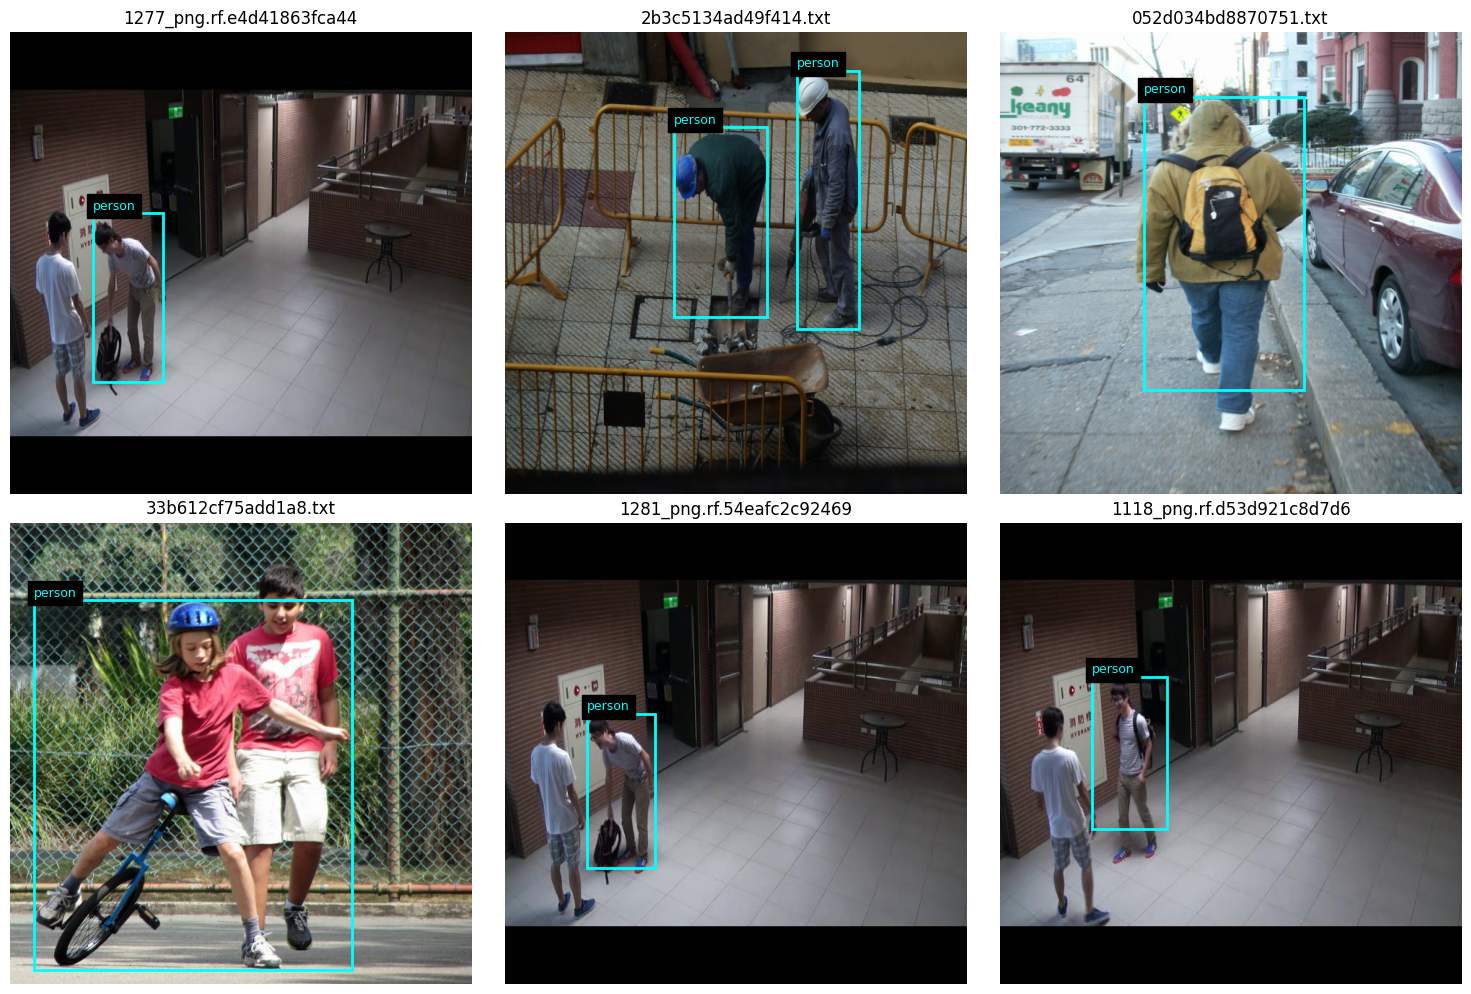

In [8]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

label_dir = "../../data/raw_data/final_unified_dataset/labels/train"
img_dir   = "../../data/raw_data/final_unified_dataset/images/train"

# Find images with person labels
person_files = []
for fname in os.listdir(label_dir):
    if not fname.endswith(".txt"):
        continue
    with open(os.path.join(label_dir, fname)) as f:
        for line in f:
            if line.startswith("0 "):
                person_files.append(fname)
                break

print(f"Images with person labels: {len(person_files)}")

# Visualise 6 random ones
sample = random.sample(person_files, 6)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, fname in zip(axes.flat, sample):
    img_path = os.path.join(img_dir, fname.replace(".txt", ".jpg"))
    if not os.path.exists(img_path):
        continue
    
    img = Image.open(img_path)
    w, h = img.size
    ax.imshow(img)
    
    with open(os.path.join(label_dir, fname)) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:])
            x1 = (cx - bw/2) * w
            y1 = (cy - bh/2) * h
            color = "cyan" if cls == 0 else "orange"
            label = "person" if cls == 0 else "bag"
            rect = patches.Rectangle(
                (x1, y1), bw*w, bh*h,
                linewidth=2, edgecolor=color, facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(x1, y1-5, label, color=color,
                   fontsize=9, backgroundcolor="black")
    
    ax.set_title(fname[:25])
    ax.axis("off")

plt.tight_layout()
plt.savefig("person_label_check.png", dpi=100)
plt.show()
EExplE

In [3]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

results = model.train(
    data="../../final_unified_dataset/dataset.yaml",
    epochs=30,              
    imgsz=640,
    batch=10,
    device=0,
    workers=4,
    patience=20,
    project="yolo8m_Dataset_v5",
    cache =True    
)

Ultralytics 8.4.24  Python-3.13.3 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=10, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../final_unified_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=